### SENTINEL — Controlled Experiments (CIE-552)

**Notebook 05** — Three controlled experiments on the Custom CNN (`SentinelLaneCNN`).
Each experiment changes **exactly one variable** and holds all others fixed.

| Experiment | Variable Changed | All others fixed |
|---|---|---|
| 1 | Input colour space (RGB / HSV / Grayscale) | model, hyperparams, data |
| 2 | Data augmentation (none / augmented) | model, hyperparams, split |
| 3 | Input distortion at test time | best model from Exp 1/2 |

Consumes `processed/labels_{train,val,test}.json` and `processed/poly_norm_stats.npz`.

---
## Cell 1 — Imports and config

In [5]:
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

# ── Constants (must match notebooks 01–03) ─────────────────────
IMG_W, IMG_H = 320, 180
LOOKAHEAD_PX = 45
SEED         = 42
PROCESSED_DIR = Path("processed")

# ── Reduced training budget for experiments ─────────────────────
# Full 50-epoch training per variant would be prohibitive.
# We use 20 epochs with early stopping (patience=5), which is sufficient
# to measure relative performance while keeping wall time manageable.
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 20
PATIENCE     = 5
LAMBDA_POLY  = 1.0
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device:      {DEVICE}")
print(f"Exp budget:  {EPOCHS} epochs, patience={PATIENCE}")

# ── Load labels and poly normalisation ────────────────────────
with open(PROCESSED_DIR / "labels_train.json", "r", encoding="utf-8") as f:
    train_labels = json.load(f)
with open(PROCESSED_DIR / "labels_val.json", "r", encoding="utf-8") as f:
    val_labels = json.load(f)
with open(PROCESSED_DIR / "labels_test.json", "r", encoding="utf-8") as f:
    test_labels = json.load(f)

stats    = np.load(str(PROCESSED_DIR / "poly_norm_stats.npz"))
POLY_MEAN = stats["mean"].astype(np.float32)
POLY_STD  = stats["std"].astype(np.float32)

print(f"Train: {len(train_labels)}  Val: {len(val_labels)}  Test: {len(test_labels)}")

Device:      cuda
Exp budget:  20 epochs, patience=5
Train: 2538  Val: 543  Test: 545


---
## Cell 2 — Shared model and training utilities

All experiments use the same `SentinelLaneCNN` architecture (Notebook 03).
The only change allowed per experiment is the input preprocessing.
Experiment 1 changes the first conv layer when `in_channels=1` (Grayscale).

In [6]:
class SentinelLaneCNN(nn.Module):
    """Same architecture as Notebook 03. in_channels=1 for grayscale."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.neck = nn.Sequential(
            nn.Linear(128 * 22 * 40, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
        )
        self.head_cls  = nn.Linear(512, 1)
        self.head_poly = nn.Linear(512, 6)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.neck(x)
        return torch.sigmoid(self.head_cls(x)), self.head_poly(x)


def multitask_loss(pred_cls, pred_poly, true_cls, true_poly):
    bce = F.binary_cross_entropy(pred_cls, true_cls)
    mask = true_cls.squeeze(1).bool()
    mse = F.mse_loss(pred_poly[mask], true_poly[mask]) if mask.sum() > 0 else torch.tensor(0.0, device=pred_cls.device)
    return bce + LAMBDA_POLY * mse, bce.item(), mse.item()


def run_epoch(loader, model, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_sum = mse_sum = 0.0
    n = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, cls_t, poly_t in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            cls_t  = cls_t.to(DEVICE, non_blocking=True)
            poly_t = poly_t.to(DEVICE, non_blocking=True)
            loss, _, mse_v = multitask_loss(*model(imgs), cls_t, poly_t)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_sum += loss.item(); mse_sum += mse_v; n += 1
    n = max(n, 1)
    return total_sum / n, mse_sum / n


def eval_metrics(model, test_labels, test_loader):
    """Return (accuracy, poly_rmse_mean, steering_mae_mean)."""
    model.eval()
    all_pred_cls  = []
    all_pred_poly = []
    all_true_cls  = []
    all_true_poly = []

    with torch.no_grad():
        for imgs, cls_t, poly_t in test_loader:
            imgs = imgs.to(DEVICE)
            pc, pp = model(imgs)
            mn = torch.from_numpy(POLY_MEAN).to(DEVICE)
            st = torch.from_numpy(POLY_STD).to(DEVICE)
            all_pred_cls.extend(pc.cpu().squeeze(1).tolist())
            all_pred_poly.extend((pp * st + mn).cpu().tolist())
            all_true_cls.extend(cls_t.squeeze(1).tolist())
            all_true_poly.extend(poly_t.tolist())

    true_poly_raw = np.array(all_true_poly, dtype=np.float32) * POLY_STD + POLY_MEAN
    pred_cls_bin  = [1 if p >= 0.5 else 0 for p in all_pred_cls]
    true_cls_bin  = [int(round(v)) for v in all_true_cls]
    accuracy      = sum(p == t for p, t in zip(pred_cls_bin, true_cls_bin)) / len(true_cls_bin)

    roi_y = int(IMG_H * 0.40)
    ys    = np.linspace(roi_y, IMG_H - 1, 30)
    y_la  = float(IMG_H - LOOKAHEAD_PX)
    rmses = []
    maes  = []

    for pp, tp, hl in zip(all_pred_poly, true_poly_raw, all_true_cls):
        if hl < 0.5:
            continue
        sq = (
            [(np.polyval(pp[:3], y) - np.polyval(tp[:3], y))**2 for y in ys] +
            [(np.polyval(pp[3:], y) - np.polyval(tp[3:], y))**2 for y in ys]
        )
        rmses.append(np.sqrt(np.mean(sq)))
        pm = (np.polyval(pp[:3], y_la) + np.polyval(pp[3:], y_la)) / 2
        tm = (np.polyval(tp[:3], y_la) + np.polyval(tp[3:], y_la)) / 2
        maes.append(abs(pm - tm))

    return accuracy, float(np.mean(rmses)) if rmses else 0.0, float(np.mean(maes)) if maes else 0.0


def train_model(train_loader, val_loader, in_channels=3, tag=""):
    """Train from scratch, return (model, history, best_val_loss)."""
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = SentinelLaneCNN(in_channels=in_channels).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3, min_lr=1e-6)

    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    patience_ctr = 0

    print(f"\nTraining [{tag}] ({in_channels}-channel input)")
    print(f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}")
    print("-" * 30)

    for epoch in range(1, EPOCHS + 1):
        tr, _ = run_epoch(train_loader, model, opt)
        vl, _ = run_epoch(val_loader,   model)
        sched.step(vl)
        history["train_loss"].append(tr)
        history["val_loss"].append(vl)

        if vl < best_val:
            best_val   = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            tag2 = " ◀"
        else:
            patience_ctr += 1
            tag2 = ""
        print(f"{epoch:6d}  {tr:9.4f}  {vl:9.4f}{tag2}")
        if patience_ctr >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history, best_val


print("Shared utilities defined.")

Shared utilities defined.


---
## Experiment 1 — Colour Space (RGB vs HSV vs Grayscale)

**Hypothesis:** HSV separates luminance from chrominance, making it more robust
to lighting variation than RGB. Grayscale loses colour information entirely,
making yellow-vs-asphalt discrimination harder.

**Protocol:** Same model architecture, same hyperparameters, same data split.
Only the input colour space changes.
- **RGB:** standard 3-channel, normalised to [0, 1]
- **HSV:** converted from BGR, each channel normalised: H÷180, S÷255, V÷255
- **Grayscale:** 1-channel luminance, normalised to [0, 1]; first conv uses `in_channels=1`

In [7]:
class ColourSpaceDataset(Dataset):
    """Lane dataset with selectable colour space: 'rgb', 'hsv', 'gray'."""

    def __init__(self, labels, poly_mean, poly_std, mode="rgb"):
        assert mode in ("rgb", "hsv", "gray")
        self.labels    = labels
        self.poly_mean = poly_mean
        self.poly_std  = poly_std
        self.mode      = mode

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl = self.labels[idx]
        img = cv2.imread(lbl["image"])
        if img is None:
            img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)

        if self.mode == "rgb":
            img_f = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        elif self.mode == "hsv":
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
            hsv[:, :, 0] /= 180.0   # H in [0,180]
            hsv[:, :, 1] /= 255.0
            hsv[:, :, 2] /= 255.0
            img_f = hsv
        else:  # gray
            gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
            img_f = gray[:, :, np.newaxis]   # H×W×1

        img_t = torch.from_numpy(img_f.transpose(2, 0, 1))

        has_lane_t = torch.tensor([1.0 if lbl["has_lane"] else 0.0])
        if lbl["has_lane"]:
            raw    = np.array(lbl["left_poly"] + lbl["right_poly"], dtype=np.float32)
            poly_t = torch.from_numpy((raw - self.poly_mean) / self.poly_std)
        else:
            poly_t = torch.zeros(6, dtype=torch.float32)

        return img_t, has_lane_t, poly_t


print("ColourSpaceDataset defined.")

ColourSpaceDataset defined.


In [8]:
exp1_results = {}
exp1_histories = {}

for cs in ["rgb", "hsv", "gray"]:
    in_ch = 1 if cs == "gray" else 3

    tr_ds = ColourSpaceDataset(train_labels, POLY_MEAN, POLY_STD, mode=cs)
    vl_ds = ColourSpaceDataset(val_labels,   POLY_MEAN, POLY_STD, mode=cs)
    te_ds = ColourSpaceDataset(test_labels,  POLY_MEAN, POLY_STD, mode=cs)

    tr_ldr = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    vl_ldr = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    te_ldr = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model, hist, bvl = train_model(tr_ldr, vl_ldr, in_channels=in_ch, tag=cs.upper())
    acc, rmse, mae   = eval_metrics(model, test_labels, te_ldr)

    exp1_results[cs]   = {"accuracy": acc, "poly_rmse": rmse, "steering_mae": mae, "best_val": bvl}
    exp1_histories[cs] = hist

    torch.save(model.state_dict(), str(PROCESSED_DIR / f"exp1_{cs}.pth"))
    print(f"  [{cs.upper()}] acc={acc:.4f}  RMSE={rmse:.2f}px  MAE={mae:.2f}px")


Training [RGB] (3-channel input)
 Epoch      Train        Val
------------------------------
     1   158.2488     0.7550 ◀
     2     1.2399     0.6458 ◀
     3     1.1204     0.6160 ◀
     4     1.1048     0.6158 ◀
     5     1.0824     0.6033 ◀
     6     1.0697     0.5983 ◀
     7     1.0529     0.5979 ◀
     8     1.0336     0.5910 ◀
     9     1.0305     0.5783 ◀
    10     1.0699     0.5736 ◀
    11     1.0136     0.5718 ◀
    12     1.0060     0.5673 ◀
    13     1.0003     0.5577 ◀
    14     1.0021     0.5542 ◀
    15     0.9907     0.5496 ◀
    16     0.9722     0.5376 ◀
    17     0.9825     0.5601
    18     0.9650     0.5478
    19     0.9744     0.5290 ◀
    20     0.9388     0.5303
  [RGB] acc=1.0000  RMSE=63.03px  MAE=51.03px

Training [HSV] (3-channel input)
 Epoch      Train        Val
------------------------------
     1   163.2035     0.6619 ◀
     2     1.1894     0.6313 ◀
     3     1.1218     0.6133 ◀
     4     1.1117     0.6110 ◀
     5     1.0828     0.6121


  Experiment 1 — Colour Space Comparison
  Space        Accuracy    Poly RMSE    Steer MAE
  ------------------------------------------------
  RGB            1.0000        63.03        51.03
  HSV            1.0000        70.95        50.25
  GRAY           1.0000        70.57        50.60

  Best colour space (lowest RMSE): RGB


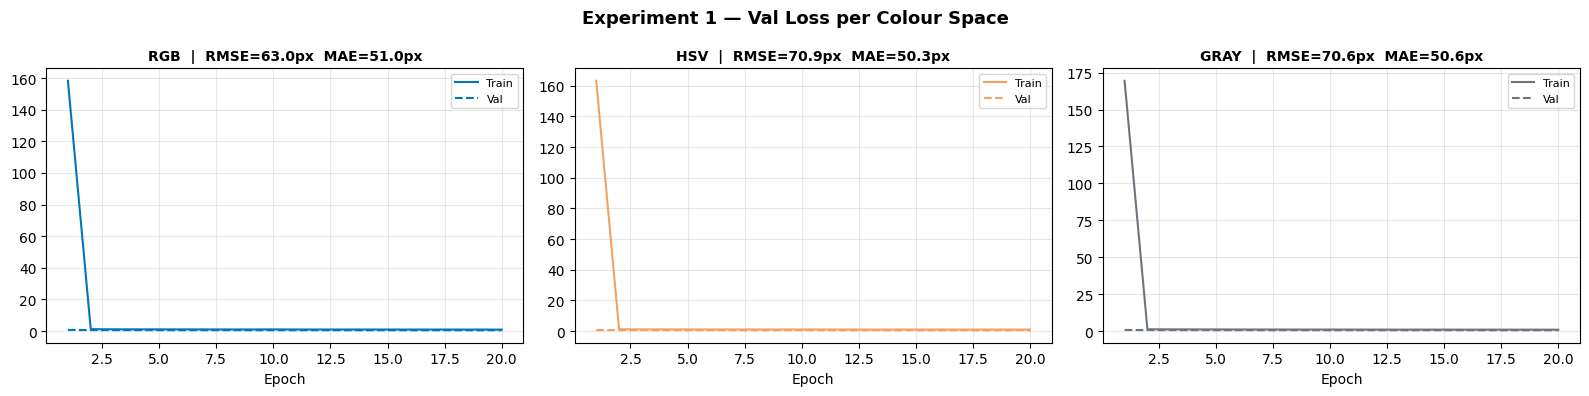

Saved: processed/exp1_colour_space.png


In [9]:
# ── Print table ───────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Experiment 1 — Colour Space Comparison")
print(f"{'='*55}")
print(f"  {'Space':<10} {'Accuracy':>10} {'Poly RMSE':>12} {'Steer MAE':>12}")
print(f"  {'-'*48}")
for cs, r in exp1_results.items():
    print(f"  {cs.upper():<10} {r['accuracy']:>10.4f} {r['poly_rmse']:>12.2f} {r['steering_mae']:>12.2f}")

best_cs = min(exp1_results, key=lambda k: exp1_results[k]["poly_rmse"])
print(f"\n  Best colour space (lowest RMSE): {best_cs.upper()}")

# ── Loss curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Experiment 1 — Val Loss per Colour Space", fontsize=13, fontweight="bold")
cs_colors = {"rgb": "#0077B6", "hsv": "#F4A261", "gray": "#6C757D"}

for ax, cs in zip(axes, ["rgb", "hsv", "gray"]):
    h = exp1_histories[cs]
    ep = list(range(1, len(h["train_loss"]) + 1))
    ax.plot(ep, h["train_loss"], label="Train", color=cs_colors[cs], linewidth=1.5)
    ax.plot(ep, h["val_loss"],   label="Val",   color=cs_colors[cs], linewidth=1.5, linestyle="--")
    r = exp1_results[cs]
    ax.set_title(f"{cs.upper()}  |  RMSE={r['poly_rmse']:.1f}px  MAE={r['steering_mae']:.1f}px",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "exp1_colour_space.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: processed/exp1_colour_space.png")

---
## Experiment 2 — Augmentation Impact (no aug vs augmented)

**Hypothesis:** Random augmentation (brightness, flip, blur, noise) should improve
generalisation by exposing the model to more varied inputs, especially under the
lighting and sensor noise conditions expected in the real RC-car environment.

**Protocol:** Same model, same hyperparameters, same data split. Only augmentation changes.

**Augmentation applied only to the training set:**
- Random brightness ±30% (V channel in HSV space)
- Horizontal flip with lane label mirroring (`x_new = IMG_W - 1 - x`)
- Gaussian blur (k=5) with probability 0.3
- Gaussian noise (σ=10/255) with probability 0.4

In [10]:
class AugmentedLaneDataset(Dataset):
    """Lane dataset with optional augmentation (training only)."""

    def __init__(self, labels, poly_mean, poly_std, augment=False):
        self.labels    = labels
        self.poly_mean = poly_mean
        self.poly_std  = poly_std
        self.augment   = augment
        self.rng       = np.random.default_rng(SEED)

    def __len__(self):
        return len(self.labels)

    def _augment(self, img_rgb, lbl):
        """Apply augmentations. Mirrors lane labels on horizontal flip."""
        img = img_rgb.copy()

        # Random brightness (HSV V channel)
        factor = 1.0 + self.rng.uniform(-0.30, 0.30)
        hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0

        # Gaussian blur
        if self.rng.random() < 0.3:
            img_u8 = (img * 255).astype(np.uint8)
            img_u8 = cv2.GaussianBlur(img_u8, (5, 5), 0)
            img = img_u8.astype(np.float32) / 255.0

        # Gaussian noise
        if self.rng.random() < 0.4:
            noise = self.rng.normal(0, 10.0 / 255.0, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        # Horizontal flip (mirror x-coords in all polys)
        flipped_lbl = lbl
        if self.rng.random() < 0.5 and lbl["has_lane"]:
            img = np.fliplr(img).copy()
            # Mirror polynomial: x_new = (IMG_W-1) - x = (IMG_W-1) - (a*y^2 + b*y + c)
            # => a_new = -a, b_new = -b, c_new = (IMG_W-1) - c
            # Swap left/right lanes after mirroring
            def mirror_poly(p):
                return [-p[0], -p[1], (IMG_W - 1) - p[2]]
            flipped_lbl = dict(lbl)
            flipped_lbl["left_poly"]  = mirror_poly(lbl["right_poly"])
            flipped_lbl["right_poly"] = mirror_poly(lbl["left_poly"])

        return img, flipped_lbl

    def __getitem__(self, idx):
        lbl = self.labels[idx]
        img = cv2.imread(lbl["image"])
        if img is None:
            img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        img_f = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        if self.augment:
            img_f, lbl = self._augment(img_f, lbl)

        img_t = torch.from_numpy(img_f.transpose(2, 0, 1))
        has_lane_t = torch.tensor([1.0 if lbl["has_lane"] else 0.0])

        if lbl["has_lane"]:
            raw    = np.array(lbl["left_poly"] + lbl["right_poly"], dtype=np.float32)
            poly_t = torch.from_numpy((raw - self.poly_mean) / self.poly_std)
        else:
            poly_t = torch.zeros(6, dtype=torch.float32)

        return img_t, has_lane_t, poly_t


print("AugmentedLaneDataset defined.")

AugmentedLaneDataset defined.


In [11]:
exp2_results   = {}
exp2_histories = {}

# Shared val/test loaders (no augmentation)
vl_ds_clean = AugmentedLaneDataset(val_labels,  POLY_MEAN, POLY_STD, augment=False)
te_ds_clean = AugmentedLaneDataset(test_labels, POLY_MEAN, POLY_STD, augment=False)
vl_ldr_clean = DataLoader(vl_ds_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
te_ldr_clean = DataLoader(te_ds_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

for aug_flag, aug_label in [(False, "no_aug"), (True, "augmented")]:
    tr_ds  = AugmentedLaneDataset(train_labels, POLY_MEAN, POLY_STD, augment=aug_flag)
    tr_ldr = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

    model, hist, bvl = train_model(tr_ldr, vl_ldr_clean, in_channels=3, tag=aug_label)
    acc, rmse, mae   = eval_metrics(model, test_labels, te_ldr_clean)

    exp2_results[aug_label]   = {"accuracy": acc, "poly_rmse": rmse, "steering_mae": mae, "best_val": bvl}
    exp2_histories[aug_label] = hist

    torch.save(model.state_dict(), str(PROCESSED_DIR / f"exp2_{aug_label}.pth"))
    print(f"  [{aug_label}] acc={acc:.4f}  RMSE={rmse:.2f}px  MAE={mae:.2f}px")


Training [no_aug] (3-channel input)
 Epoch      Train        Val
------------------------------
     1   158.3717     0.7576 ◀
     2     1.2429     0.6468 ◀
     3     1.1220     0.6166 ◀
     4     1.1043     0.6172
     5     1.0860     0.6039 ◀
     6     1.0556     0.5969 ◀
     7     1.0497     0.5992
     8     1.0313     0.5877 ◀
     9     1.0225     0.5744 ◀
    10     1.0349     0.5730 ◀
    11     1.0129     0.5648 ◀
    12     0.9958     0.5566 ◀
    13     0.9945     0.5450 ◀
    14     1.0000     0.5507
    15     0.9799     0.5418 ◀
    16     0.9701     0.5291 ◀
    17     0.9709     0.5664
    18     0.9592     0.5601
    19     0.9770     0.5356
    20     0.9404     0.5275 ◀
  [no_aug] acc=1.0000  RMSE=60.45px  MAE=46.41px

Training [augmented] (3-channel input)
 Epoch      Train        Val
------------------------------
     1   149.9091     0.7455 ◀
     2     1.6371     0.6701 ◀
     3     1.5811     0.6379 ◀
     4     1.5913     0.6280 ◀
     5     1.4842     


  Experiment 2 — Augmentation Impact
  Variant        Accuracy    Poly RMSE    Steer MAE
  ------------------------------------------------
  no_aug           1.0000        60.45        46.41
  augmented        1.0000        60.93        48.55


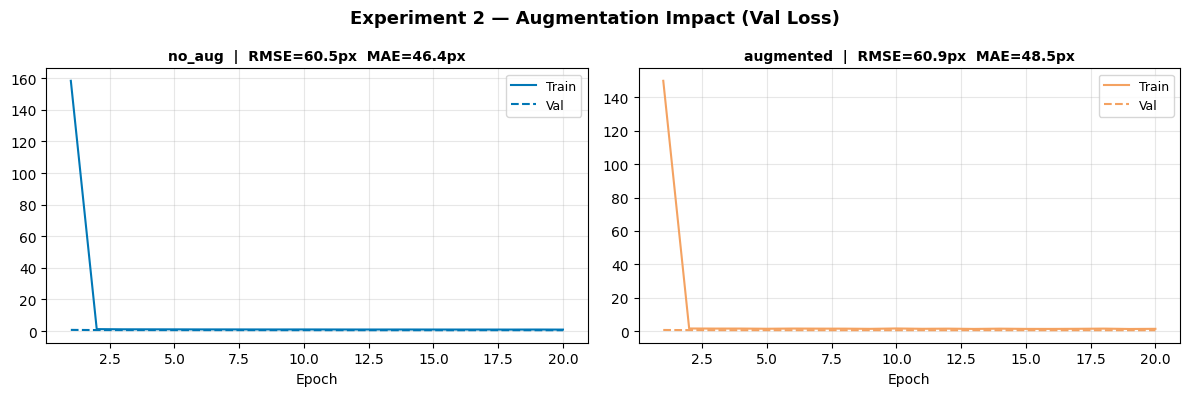

Saved: processed/exp2_augmentation.png


In [12]:
# ── Print table ───────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Experiment 2 — Augmentation Impact")
print(f"{'='*55}")
print(f"  {'Variant':<12} {'Accuracy':>10} {'Poly RMSE':>12} {'Steer MAE':>12}")
print(f"  {'-'*48}")
for label, r in exp2_results.items():
    print(f"  {label:<12} {r['accuracy']:>10.4f} {r['poly_rmse']:>12.2f} {r['steering_mae']:>12.2f}")

# ── Side-by-side val loss curves ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 2 — Augmentation Impact (Val Loss)", fontsize=13, fontweight="bold")

for ax, (label, color) in zip(axes, [("no_aug", "#0077B6"), ("augmented", "#F4A261")]):
    h = exp2_histories[label]
    ep = list(range(1, len(h["train_loss"]) + 1))
    ax.plot(ep, h["train_loss"], label="Train", color=color, linewidth=1.5)
    ax.plot(ep, h["val_loss"],   label="Val",   color=color, linewidth=1.5, linestyle="--")
    r = exp2_results[label]
    ax.set_title(f"{label}  |  RMSE={r['poly_rmse']:.1f}px  MAE={r['steering_mae']:.1f}px",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "exp2_augmentation.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: processed/exp2_augmentation.png")

---
## Experiment 3 — Distortion Robustness

**Hypothesis:** Models trained on clean data will degrade under real-world
sensor distortions. Augmented models should degrade less.

**Protocol:** Take the best model from Experiments 1 and 2 (highest performance
on the colour space / augmentation axes). Evaluate it on the clean test set and
four distorted variants. **No retraining — distortions applied only at test time.**

Distortions:
1. **Clean** — baseline
2. **Gaussian noise** — σ=15/255 added per pixel
3. **Brightness shift** — multiply V channel by 0.5 (dark scene)
4. **Gaussian blur** — kernel 7×7
5. **Combined** — noise + brightness + blur

In [13]:
# Determine best model from exp 1 (colour space) and exp 2 (augmentation)
best_cs_key  = min(exp1_results, key=lambda k: exp1_results[k]["poly_rmse"])
best_aug_key = min(exp2_results, key=lambda k: exp2_results[k]["poly_rmse"])

print(f"Best colour space: {best_cs_key.upper()} (RMSE={exp1_results[best_cs_key]['poly_rmse']:.2f}px)")
print(f"Best augmentation: {best_aug_key} (RMSE={exp2_results[best_aug_key]['poly_rmse']:.2f}px)")

# Load the augmentation-experiment winner (trained on RGB) as the test model
# RGB is used for comparability: all distortions are applied in RGB space
best_model_path = PROCESSED_DIR / f"exp2_{best_aug_key}.pth"
best_model = SentinelLaneCNN(in_channels=3).to(DEVICE)
best_model.load_state_dict(torch.load(str(best_model_path), map_location=DEVICE))
best_model.eval()
print(f"\nLoaded model: {best_model_path}")


def apply_distortion(img_rgb_f32, mode):
    """Apply a distortion to a float32 RGB image in [0,1]. Returns distorted copy."""
    img = img_rgb_f32.copy()
    rng = np.random.default_rng(0)  # fixed seed for reproducibility

    if mode == "noise":
        noise = rng.normal(0, 15.0 / 255.0, img.shape).astype(np.float32)
        img   = np.clip(img + noise, 0.0, 1.0)

    elif mode == "brightness":
        hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 0.5, 0, 255)
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0

    elif mode == "blur":
        img_u8 = (img * 255).astype(np.uint8)
        img_u8 = cv2.GaussianBlur(img_u8, (7, 7), 0)
        img    = img_u8.astype(np.float32) / 255.0

    elif mode == "combined":
        noise  = rng.normal(0, 15.0 / 255.0, img.shape).astype(np.float32)
        img    = np.clip(img + noise, 0.0, 1.0)
        hsv    = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 0.5, 0, 255)
        img    = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
        img_u8 = (img * 255).astype(np.uint8)
        img_u8 = cv2.GaussianBlur(img_u8, (7, 7), 0)
        img    = img_u8.astype(np.float32) / 255.0

    return img


print("Distortion utilities defined.")

Best colour space: RGB (RMSE=63.03px)
Best augmentation: no_aug (RMSE=60.45px)

Loaded model: processed/exp2_no_aug.pth
Distortion utilities defined.


In [14]:
class DistortedLaneDataset(Dataset):
    """Test dataset with a fixed distortion applied to every image."""

    def __init__(self, labels, poly_mean, poly_std, distortion="clean"):
        self.labels      = labels
        self.poly_mean   = poly_mean
        self.poly_std    = poly_std
        self.distortion  = distortion

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl = self.labels[idx]
        img = cv2.imread(lbl["image"])
        if img is None:
            img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        img_f = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        if self.distortion != "clean":
            img_f = apply_distortion(img_f, self.distortion)

        img_t = torch.from_numpy(img_f.transpose(2, 0, 1))
        has_lane_t = torch.tensor([1.0 if lbl["has_lane"] else 0.0])
        if lbl["has_lane"]:
            raw    = np.array(lbl["left_poly"] + lbl["right_poly"], dtype=np.float32)
            poly_t = torch.from_numpy((raw - self.poly_mean) / self.poly_std)
        else:
            poly_t = torch.zeros(6, dtype=torch.float32)
        return img_t, has_lane_t, poly_t


distortions = ["clean", "noise", "brightness", "blur", "combined"]
exp3_results = {}

for dist in distortions:
    te_ds  = DistortedLaneDataset(test_labels, POLY_MEAN, POLY_STD, distortion=dist)
    te_ldr = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    acc, rmse, mae = eval_metrics(best_model, test_labels, te_ldr)
    exp3_results[dist] = {"accuracy": acc, "poly_rmse": rmse, "steering_mae": mae}
    print(f"  [{dist:<12}] acc={acc:.4f}  RMSE={rmse:.2f}px  MAE={mae:.2f}px")

  [clean       ] acc=1.0000  RMSE=60.45px  MAE=46.41px
  [noise       ] acc=1.0000  RMSE=65.73px  MAE=52.71px
  [brightness  ] acc=1.0000  RMSE=62.88px  MAE=45.67px
  [blur        ] acc=1.0000  RMSE=60.48px  MAE=45.56px
  [combined    ] acc=1.0000  RMSE=62.53px  MAE=45.61px



  Experiment 3 — Distortion Robustness
  (Model: exp2_no_aug)
  Distortion       Accuracy    Poly RMSE    Steer MAE
  ----------------------------------------------------
  clean              1.0000        60.45        46.41
  noise              1.0000        65.73        52.71
  brightness         1.0000        62.88        45.67
  blur               1.0000        60.48        45.56
  combined           1.0000        62.53        45.61


/tmp/ipykernel_17626/707380504.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dist_labels, rotation=20, ha="right")
/tmp/ipykernel_17626/707380504.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dist_labels, rotation=20, ha="right")


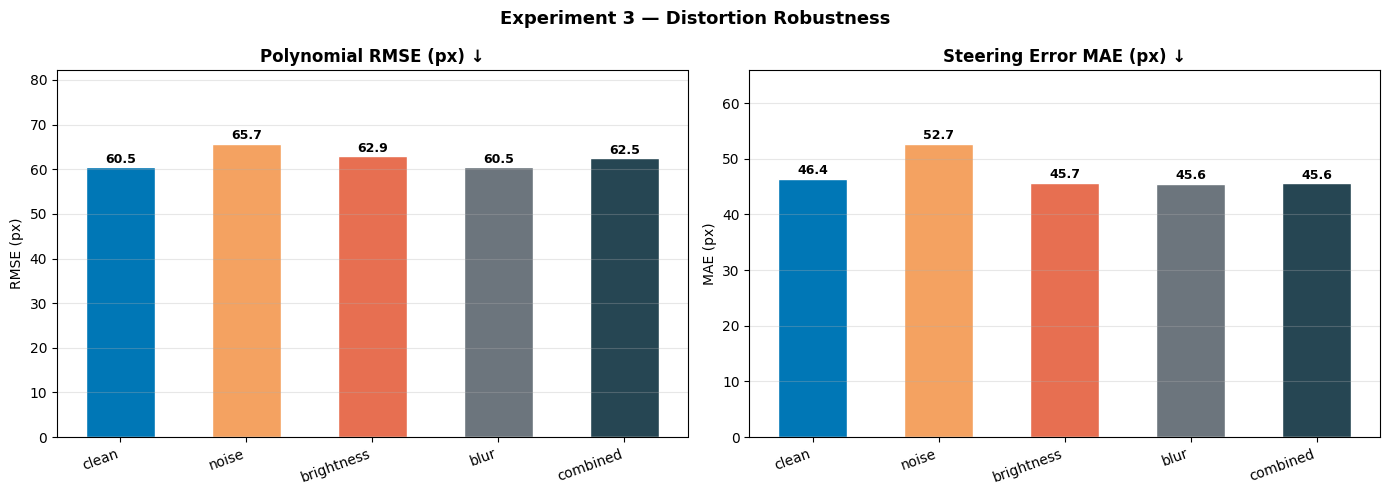

Saved: processed/exp3_distortion.png
Saved: processed/experiment_results.json

Notebook 05 complete. Next: 06_deployment.ipynb


In [15]:
# ── Print table ───────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Experiment 3 — Distortion Robustness")
print(f"  (Model: exp2_{best_aug_key})")
print(f"{'='*60}")
print(f"  {'Distortion':<14} {'Accuracy':>10} {'Poly RMSE':>12} {'Steer MAE':>12}")
print(f"  {'-'*52}")
for dist, r in exp3_results.items():
    print(f"  {dist:<14} {r['accuracy']:>10.4f} {r['poly_rmse']:>12.2f} {r['steering_mae']:>12.2f}")

# ── Bar chart — Steering MAE per distortion ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Experiment 3 — Distortion Robustness", fontsize=13, fontweight="bold")

dist_labels = list(exp3_results.keys())
rmse_vals   = [exp3_results[d]["poly_rmse"]     for d in dist_labels]
mae_vals    = [exp3_results[d]["steering_mae"]  for d in dist_labels]
bar_colors  = ["#0077B6", "#F4A261", "#E76F51", "#6C757D", "#264653"]

for ax, vals, ylabel, title in [
    (axes[0], rmse_vals, "RMSE (px)",  "Polynomial RMSE (px) ↓"),
    (axes[1], mae_vals,  "MAE (px)",   "Steering Error MAE (px) ↓"),
]:
    bars = ax.bar(dist_labels, vals, color=bar_colors, edgecolor="white", width=0.55)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(dist_labels, rotation=20, ha="right")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "exp3_distortion.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: processed/exp3_distortion.png")

# ── Save all experiment results ───────────────────────────────
all_exp_results = {
    "exp1_colour_space": exp1_results,
    "exp2_augmentation": exp2_results,
    "exp3_distortion":   exp3_results,
}
with open(str(PROCESSED_DIR / "experiment_results.json"), "w", encoding="utf-8") as f:
    json.dump(all_exp_results, f, indent=2)
print("Saved: processed/experiment_results.json")
print("\nNotebook 05 complete. Next: 06_deployment.ipynb")